Import the necessary libraries 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load the csv dataset

In [3]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,58,1,1,142,228,0,1,135,0,0.9,1,0,2,1
1,53,1,0,130,228,1,1,124,1,1.3,1,0,3,0
2,60,1,3,142,229,0,0,140,1,1.3,2,1,2,1
3,68,1,1,134,353,0,1,124,0,0.1,2,0,3,0
4,52,1,2,108,266,0,1,144,0,2.8,2,0,3,0


The first five data of the heart dataset is loaded that contains the medical information of the patient. The goal is to identify which factors are most related to the heart disease

Lets first know more information about the data like shape, data types and first few rows.

In [13]:
df.shape
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,53.795380,0.686469,1.831683,133.511551,248.141914,0.125413,0.547855,148.448845,0.356436,1.310561,1.382838,0.693069,2.260726,0.478548
std,8.741943,0.464696,1.089407,16.438900,52.141075,0.331734,0.524424,21.920911,0.479738,0.877999,0.618669,1.023653,0.662132,0.500366
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,1.000000,122.000000,211.000000,0.000000,0.000000,135.000000,0.000000,0.600000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,2.000000,134.000000,248.000000,0.000000,1.000000,149.000000,0.000000,1.200000,1.000000,0.000000,2.000000,0.000000
75%,60.000000,1.000000,3.000000,144.000000,279.000000,0.000000,1.000000,163.000000,1.000000,1.900000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,175.000000,379.000000,1.000000,2.000000,202.000000,1.000000,3.600000,2.000000,4.000000,3.000000,1.000000


Total Rows: 303
Total Columns: 14



Check the messiness of the data. Clean the data

In [14]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

No duplicate or null values found in the dataset. If missing values or duplicates were present we need to handle it separately

Also lets check outliers for the numerical columns. check carefully to see if data is showing patterns at numbers or just random data

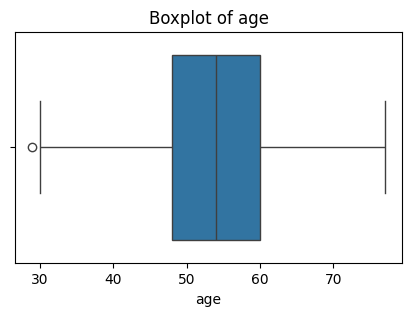

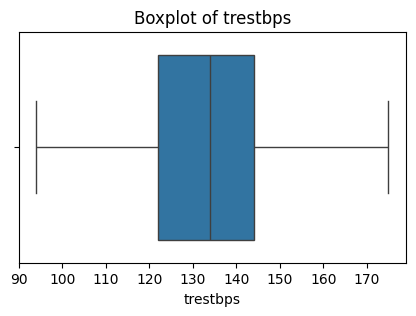

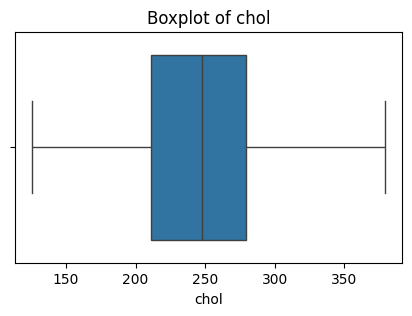

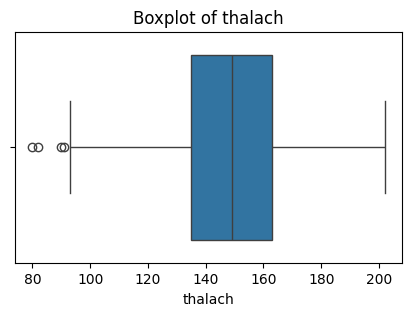

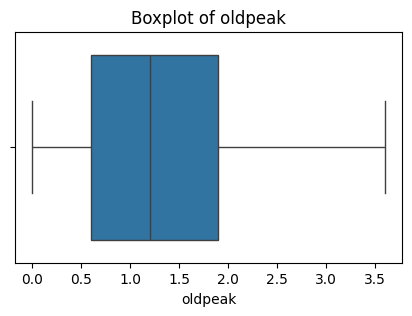

In [19]:
num_cols=["age","trestbps","chol","thalach","oldpeak"]

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

chol and trestbps shows extreme values but these may represent some genuine medical cases so they are kept

Now doing univariate analysis on each of the features Lets start with the target variable

Lets use countplot as the target column contains categorical data and is nominal data
as there is no hierarchy
0=No heart disease
1= Heart disease

Histplot is used when column contains numbers to see the number distribution

countplot=Used when the column contains groups/categories.

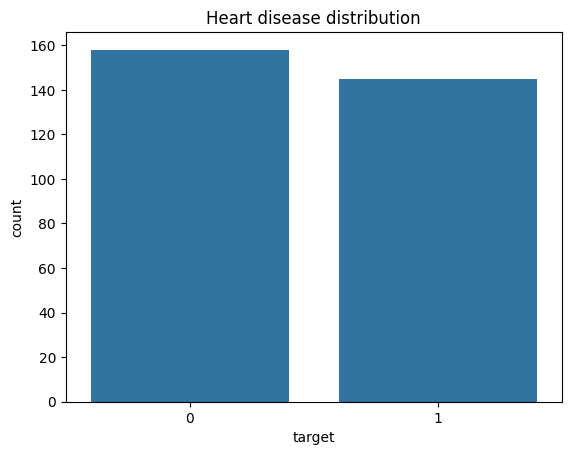

target
0    158
1    145
Name: count, dtype: int64


In [ ]:

sns.countplot(x="target",data=df)

plt.title("Heart disease distribution")
plt.show()

print(df["target"].value_counts())

The dataset is fairly balanced the gap is not that huge. The people with heart disease are 145 and people having no heart disease are 158

Univariate Analysis on age

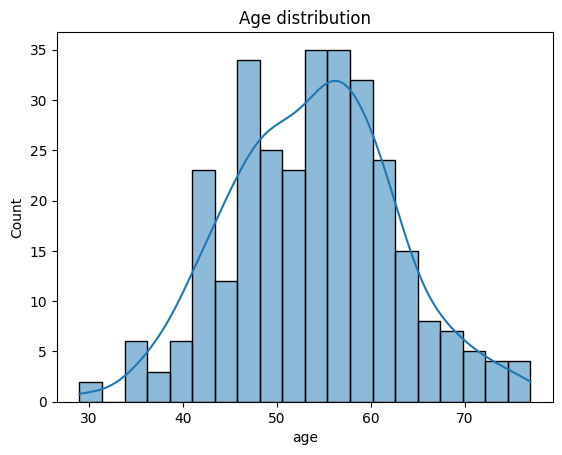

In [12]:
sns.histplot(df["age"], bins=20,kde=True )
plt.title("Age distribution")
plt.show()


Insight: Most patient are between 45-65 years old

Univariate analysis on sex

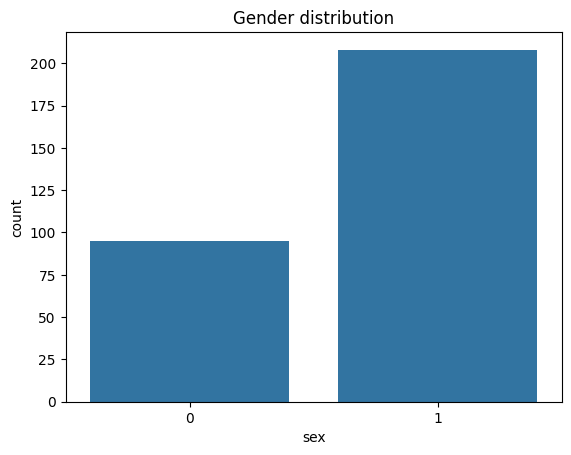

sex
0    31.353135
1    68.646865
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x="sex",data=df)
plt.title("Gender distribution");
plt.show()

print(df['sex'].value_counts(normalize=True).sort_index()*100)

Most patients are male 
0= Female
1=Male



Univariate analysis on chest pain



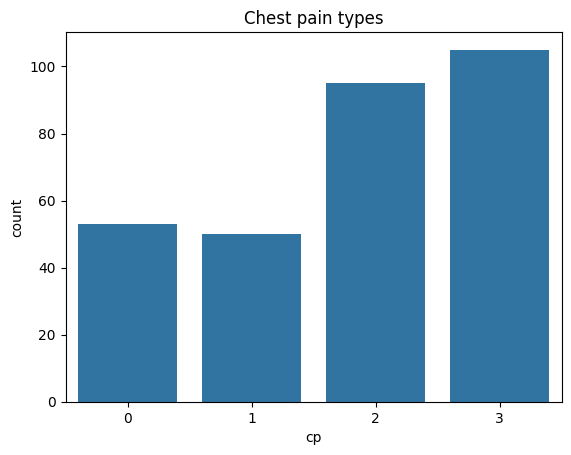

In [15]:
sns.countplot(x="cp", data=df)
plt.title("Chest pain types")
plt.show()


Chest pain types 2 and 3 are most common 

Resting blood pressure

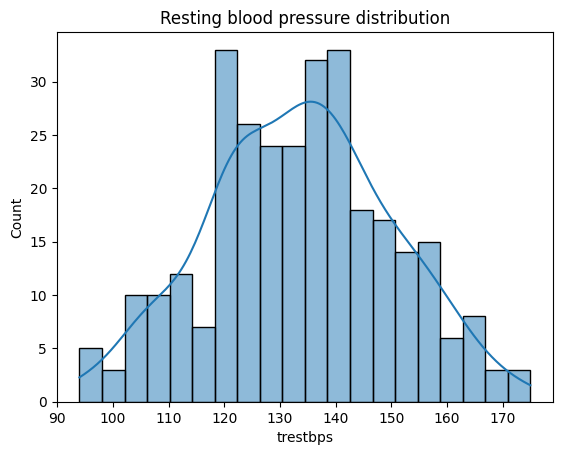

trestbps
94     0.990099
95     0.330033
98     0.330033
101    0.330033
102    0.660066
         ...   
167    0.330033
169    0.660066
171    0.330033
174    0.330033
175    0.330033
Name: proportion, Length: 70, dtype: float64


In [10]:
sns.histplot(df["trestbps"], bins=20,kde=True )
plt.title("Resting blood pressure distribution")
plt.show()

print(df['trestbps'].value_counts(normalize=True).sort_index()*100)

The resting blood pressure (trestbps) distribution is approximately normal with most patients having values between 120 and 145 mmHg and a peak around 130–140 mmHg.

Cholesterol

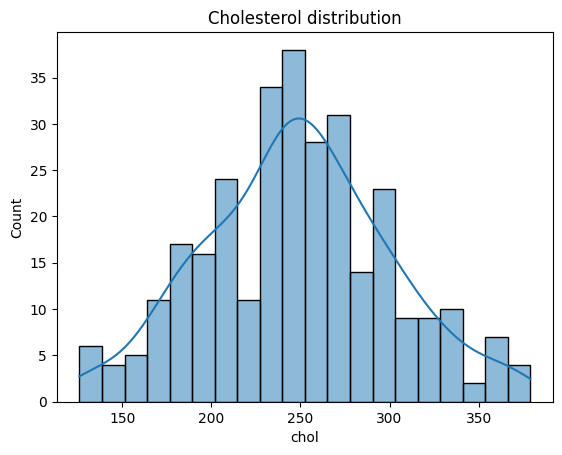

chol
126    1.320132
134    0.660066
142    0.330033
143    0.660066
151    0.330033
         ...   
366    0.330033
370    0.330033
372    0.330033
375    0.330033
379    0.330033
Name: proportion, Length: 161, dtype: float64


In [ ]:
sns.histplot(df["chol"],bins=20,kde=True )
plt.title("Cholesterol distribution")
plt.show()

print(df['chol'].value_counts(normalize=True).sort_index()*100)

Most patients have cholesterol levels in a common range while a few patients have very high cholesterol levels.

Bivariate Analysis

Age vs Heart Disease

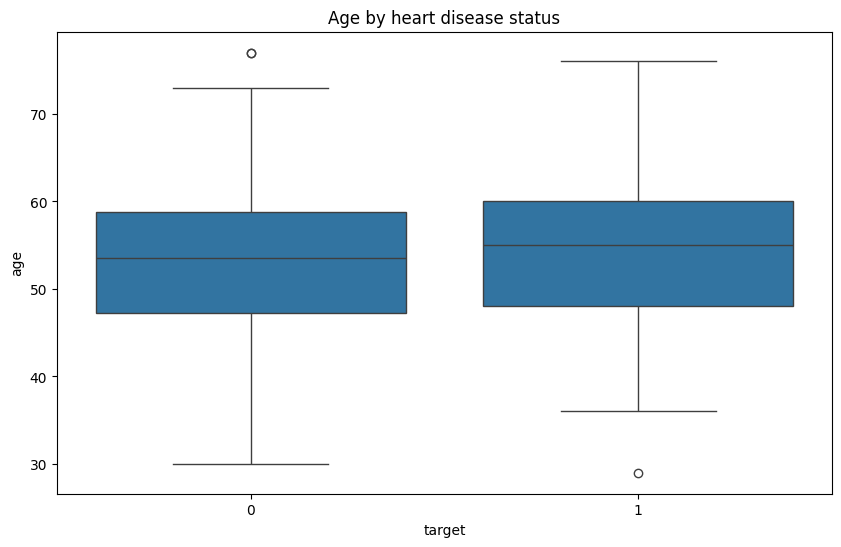

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x="target", y="age", data=df)
plt.title("Age by heart disease status")
plt.show()

Individuals with heart disease are seen to be slightly older however distributions overlap with each other so age alone is not sufficient.

Gender vs Heart disease

In [21]:
pd.crosstab(df["sex"], df["target"], normalize="index")*100



target,0,1
sex,,
0,36.842105,63.157895
1,59.134615,40.865385


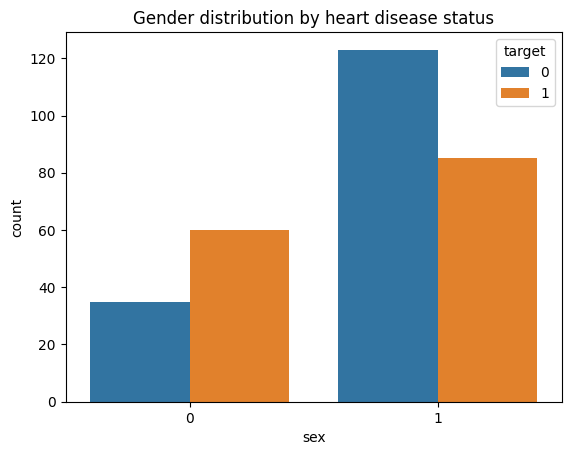

In [22]:
sns.countplot(x="sex", hue="target", data=df)
plt.title("Gender distribution by heart disease status")
plt.show()

Females tend to have higher chances of heart disease 63.15% than male 40.86%

sex
0    0.631579
1    0.408654
Name: target, dtype: float64

Chest Pain Type vs Heart Disease

In [ ]:
cp_percent = pd.crosstab(df["cp"],
df["target"],normalize="index")*100

cp_percent

target,0,1
cp,,
0,75.471698,24.528302
1,46.000000,54.000000
2,43.157895,56.842105
3,51.428571,48.571429


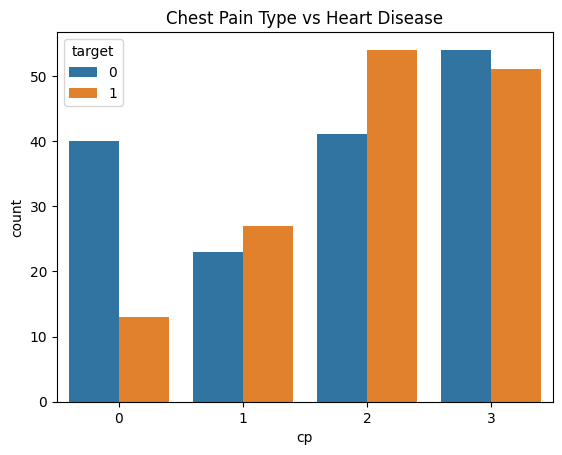

In [ ]:
sns.countplot(x="cp",hue="target",data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.show()

Some chest pain categories like 0, 2 and 3 show higher heart disease rates.
 Thus, Chest pain is an important predictor.

Exercise Induced Angina vs Heart Disease


In [26]:
pd.crosstab(df["exang"], df["target"])

target,0,1
exang,,
0,114,81
1,44,64


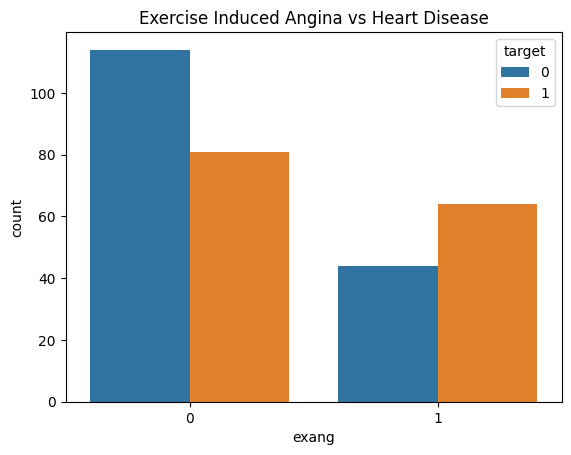

In [ ]:
sns.countplot(x="exang",hue="target",
data=df)

plt.title("Exercise Induced Angina vs Heart Disease")
plt.show()

Patients experiencing exercise-induced angina are more likely to have heart disease.

Key findings:
1) The dataset has clean records with no missing and duplicates values
2) Most patient age are between 45 and 65 years old showing that heart disease is more commonly observed among middle aged and older adults
3) Female patient shows a higher proportion of heart disease compared to male within the dataset
4) Chest pain shows strong association with heart disease status
5) Exercise induced angina is an important indictor and shows that patient experiencing angina are more likely to have heart disease

Summary:
The analysis showed that patients with certain chest pain patterns and those who experienced angina during exercise were more likely to have heart disease. Older patients also appeared to be at greater risk compared to younger individuals. Heart-rate-related measures and exercise test results provided stronger signals than cholesterol or resting blood pressure alone.